In [ ]:
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import os

In [ ]:
#Импорт всех фоток с репозитория
dataset = load_dataset("tukey/documents_email", split="train")
os.makedirs("downloaded_images", exist_ok=True)

for i, example in enumerate(dataset):
    # 'image' — это стандартное имя колонки для картинок
    example['image'].save(f"downloaded_images/img_{i}.jpg")


c:\Users\savva\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Сбор кол-ва классов по всем фоткам
labels_path = "./ResultMark Dataset/data/labels/train"  # путь к папке
counter = Counter()

for file in os.listdir(labels_path):
    if file.endswith(".txt"):
        with open(os.path.join(labels_path, file), "r") as f:
            for line in f:
                class_id = int(line.split()[0])
                counter[class_id] += 1

print(counter)

Counter({1: 226, 2: 224, 0: 221, 4: 221, 5: 216, 3: 162})


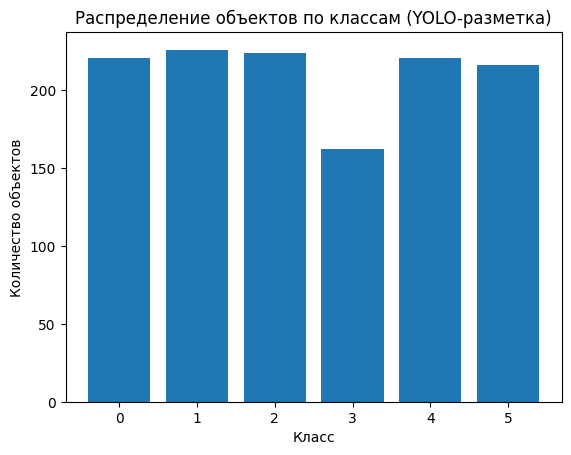

In [ ]:
#Построение графика для визуализации
data = counter

# sort by class id
classes = sorted(data.keys())
values = [data[c] for c in classes]

plt.figure()
plt.bar([str(c) for c in classes], values)
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.title("Распределение объектов по классам (YOLO-разметка)")

plt.savefig('./DiagrammYolo.png')
plt.show()